# Análise - Pilotos que mais ganham ou perdem posições entre largada e chegada

##  1. Introdução

Na Fórmula 1, a posição de largada é um fator crucial que pode influenciar diretamente o resultado final da corrida. Pilotos que largam nas primeiras posições geralmente têm maior vantagem para manter ou conquistar boas colocações ao longo da prova. Esta análise busca entender quantitativamente qual é a relação entre a posição no grid e a posição final dos pilotos, utilizando dados históricos das corridas.

## 2. Objetivo

Os objetivos principais desta Análise Exploratória de Dados (EDA) são:

    - Avaliar a correlação entre a posição de largada (obtida no qualifying) e a posição final (resultado da corrida) para cada piloto.

    - Calcular o coeficiente de correlação de Pearson para quantificar o grau de associação entre largar bem e terminar bem.


## 3. Metodologia
Inicialmente, foram utilizadas três bases de dados principais:

    - qualifying.csv: Contém as posições de largada dos pilotos, baseadas no treino classificatório;

    - results.csv: Apresenta os resultados finais de cada corrida (posição de chegada real);

#### 3.1 Carregamento, Filtragem e Pré-processamento dos Dados

In [2]:
import pandas as pd
from scipy.stats import pearsonr
import numpy as np

# Carregamento dos dados
qualifying = pd.read_csv('qualifying.csv')
results = pd.read_csv('results.csv')

# Seleção e renomeação das colunas relevantes
qualifying_filtered = qualifying[['raceId', 'driverId', 'position']].rename(columns={'position': 'grid_position'})
results_filtered = results[['raceId', 'driverId', 'positionOrder']].rename(columns={'positionOrder': 'final_position'})

# União dos dados de largada e chegada
merged = pd.merge(qualifying_filtered, results_filtered, on=['raceId', 'driverId'])

# Remoção de dados faltantes
merged = merged.dropna()

# Cálculo da correlação de Pearson entre posição no grid e posição final
corr, p_value = pearsonr(merged['grid_position'], merged['final_position'])

# Resultados
print(f"Correlação entre posição de largada e posição final: {corr:.3f} (p = {p_value:.3f})")


Correlação entre posição de largada e posição final: 0.576 (p = 0.000)


## 4. Pilotos que mais ganham ou perdem posições entre largada e chegada

A análise da relação entre posição de largada e posição final nas corridas de Fórmula 1 revelou alguns pontos importantes:

    - Há uma correlação positiva significativa, indicando que pilotos que largam mais à frente tendem a terminar a corrida em melhores posições;

    - Contudo, a variabilidade mostrada nos boxplots evidencia que mudanças de posição são comuns, especialmente para pilotos largando do meio para trás do grid;

Isso sugere que, apesar da vantagem de largar nas primeiras posições, a corrida apresenta muitos fatores dinâmicos que podem alterar o resultado final, como ultrapassagens, estratégias e eventos durante a prova.

Correlação entre posição de largada e posição final: 0.576 (p = 0.000)


/var/folders/5z/p9vk7tg12wq_vpmfx1kgwpg40000gn/T/ipykernel_3681/4135174825.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='grid_position', y='final_position', data=top_grid, palette='Blues')


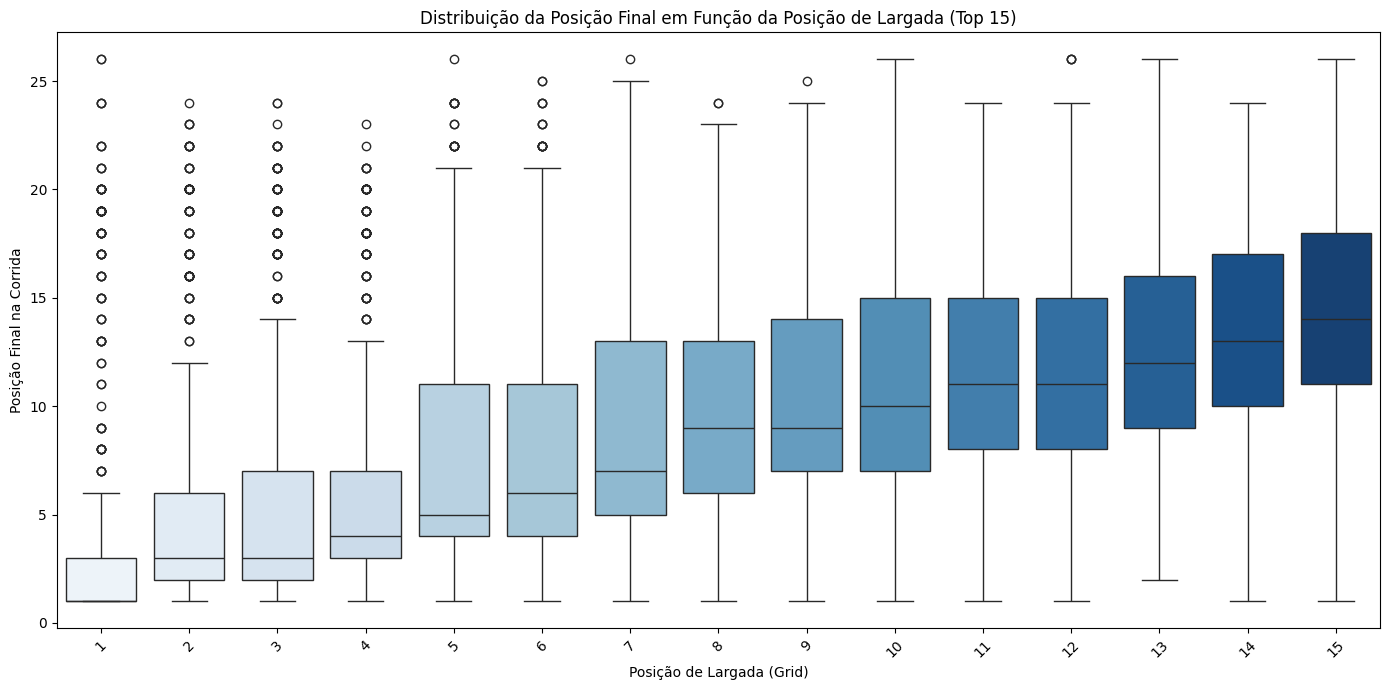

In [4]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# Carregamento dos dados
qualifying = pd.read_csv('qualifying.csv')
results = pd.read_csv('results.csv')

# Seleção e renomeação das colunas relevantes
qualifying_filtered = qualifying[['raceId', 'driverId', 'position']].rename(columns={'position': 'grid_position'})
results_filtered = results[['raceId', 'driverId', 'positionOrder']].rename(columns={'positionOrder': 'final_position'})

# União dos dados de largada e chegada
merged = pd.merge(qualifying_filtered, results_filtered, on=['raceId', 'driverId'])

# Remoção de dados faltantes
merged = merged.dropna()

# Cálculo da correlação de Pearson entre posição no grid e posição final
corr, p_value = pearsonr(merged['grid_position'], merged['final_position'])

print(f"Correlação entre posição de largada e posição final: {corr:.3f} (p = {p_value:.3f})")

# Para facilitar a visualização, filtrar posições de largada de 1 a 15 (top 15 no grid)
top_grid = merged[(merged['grid_position'] <= 15)]

# Plot: boxplot mostrando a distribuição da posição final para cada posição de largada no top 15
plt.figure(figsize=(14,7))
sns.boxplot(x='grid_position', y='final_position', data=top_grid, palette='Blues')
plt.title('Distribuição da Posição Final em Função da Posição de Largada (Top 15)')
plt.xlabel('Posição de Largada (Grid)')
plt.ylabel('Posição Final na Corrida')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
